# **A Deep Learning Solution to Predict Song Popularity for Music Streaming Platforms**

 *Section C Team 45:
Sam MacArthur, Chris Chen, Ziling Chen, Krishna Gupta, Neha Maqsood*


In the modern era of music, online streaming platforms have become the central way to listen to music and explore new musical artists. Many of the big-name firms dominating this industry (Spotify, Apple Music, SoundCloud, etc.) constantly seek a competitive edge to improve revenue generation and user retention over their rivals. As a core element of the music industry, gaining insight into what music will be popular is essential to preventing user churn and maintaining market share. While there is no way to predict future song popularity with 100% certainty, deep learning can be utilized to provide reasonable estimates on the subject. In this project, we plan to utilize historical music data to develop a deep learning model that can provide an accurate estimate of the popularity of a new song or artist.

### **Data Loading and Pre-Processing**

In [ ]:
import zipfile
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split


In [ ]:
!unzip song_data.zip

unzip:  cannot find or open song_data.zip, song_data.zip.zip or song_data.zip.ZIP.


In [ ]:
song_data = pd.read_csv('song_data.csv')
print(song_data.shape)
print(song_data.columns)

(18835, 15)
Index(['song_name', 'song_popularity', 'song_duration_ms', 'acousticness',
       'danceability', 'energy', 'instrumentalness', 'key', 'liveness',
       'loudness', 'audio_mode', 'speechiness', 'tempo', 'time_signature',
       'audio_valence'],
      dtype='object')


Preliminary Analysis

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

song_data.dropna(subset=['song_popularity'], inplace=True)

# stratification for popularity bins
bins = [0, 30, 60, 100]
labels = ['low', 'mid', 'high']
song_data['pop_bin'] = pd.cut(song_data['song_popularity'], bins=bins, labels=labels, include_lowest = True)


train_df, test_df = train_test_split(song_data, test_size=0.2, random_state=42, stratify=song_data['pop_bin'])

train_df = train_df.drop(['song_name', 'pop_bin'], axis=1)
test_df = test_df.drop(['song_name', 'pop_bin'], axis=1)



print(train_df.shape)
print(test_df.columns)

(15068, 14)
Index(['song_popularity', 'song_duration_ms', 'acousticness', 'danceability',
       'energy', 'instrumentalness', 'key', 'liveness', 'loudness',
       'audio_mode', 'speechiness', 'tempo', 'time_signature',
       'audio_valence'],
      dtype='object')


Overall distribution & Distribution by popularity bins

Text(0.5, 1.0, 'Overall Distribution')

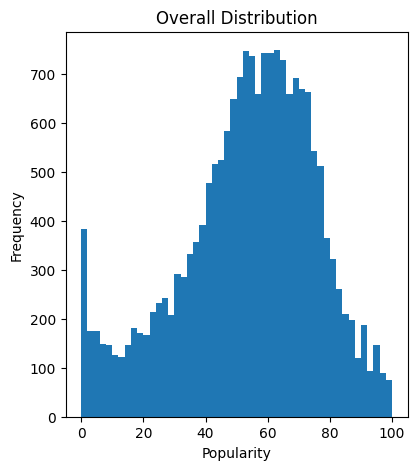

In [ ]:
#Overall distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.hist(song_data['song_popularity'], bins=50)
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.title('Overall Distribution')

Text(0.5, 1.0, 'Distribution by Popularity Bin')

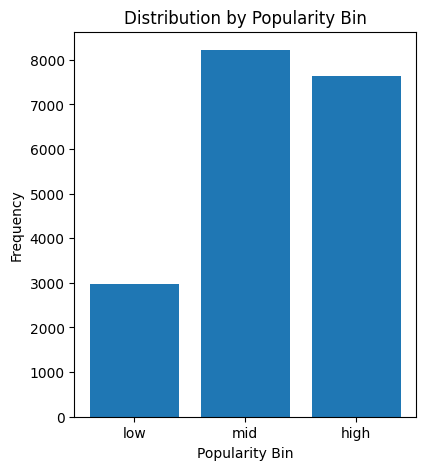

In [ ]:
#distribution by popularity bins
bins = [0, 30, 60, 100]
labels = ['low', 'mid', 'high']
song_data['pop_bin'] = pd.cut(song_data['song_popularity'], bins=bins, labels=labels, include_lowest=True)
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
bin_counts = song_data['pop_bin'].value_counts(sort=False)
plt.bar(bin_counts.index, bin_counts.values)
plt.xlabel('Popularity Bin')
plt.ylabel('Frequency')
plt.title('Distribution by Popularity Bin')

For reference regarding bin distribution: "low" represents popularity scores between (0-30), "medium" (30-60), and "high" (60-100).

Standardizing and Converting Features to PyTorch Tensors

In [ ]:
#standardizing
from sklearn.preprocessing import StandardScaler
x_train = train_df.drop(['song_popularity'], axis=1)
y_train = train_df['song_popularity']
x_test = test_df.drop(['song_popularity'], axis=1)
y_test = test_df['song_popularity']

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

print(x_train.shape)
print(x_test.shape)

(15068, 13)
(3767, 13)


In [ ]:
#converting to tensors
import torch
x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)


### **DataLoaders and Batching**

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(x_train, y_train)
test_dataset = TensorDataset(x_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


Given what we see in the distributions above, we need to change penalize low popularity errors more than medium and high

In [ ]:
import torch.nn as nn
import torch

class WeightedMSELoss(nn.Module):
    def __init__(self, low_t=40, low_weight=2.5):
        super(WeightedMSELoss, self).__init__()
        self.low_t = low_t
        self.low_weight = low_weight

    def forward(self, y_pred, y_true):
        squared_errors = (y_pred - y_true) ** 2
        weights = torch.where(y_true < self.low_t,
                              torch.tensor(self.low_weight, device=y_true.device),
                              torch.tensor(1.0, device=y_true.device))
        weighted_mse = (weights * squared_errors).mean()
        return weighted_mse

#test weighted loss to make sure this works
test_predictions = torch.tensor([[45], [55], [25], [35]])
test_targets = torch.tensor([[50.0], [60.0], [20.0], [30.0]])
regular_loss = nn.MSELoss()(test_predictions, test_targets)
weighted_loss_fn = WeightedMSELoss(low_t=40, low_weight=2.5)
weighted_loss = weighted_loss_fn(test_predictions, test_targets)

print(f"Regular MSE: {regular_loss.item():.3f}")
print(f"Weighted MSE: {weighted_loss.item():.3f}")
print(f"Weight applied to low-popularity samples (< 40)")
print(f"Higher loss encourages model to focus on low-popularity predictions")

Regular MSE: 25.000
Weighted MSE: 43.750
Weight applied to low-popularity samples (< 40)
Higher loss encourages model to focus on low-popularity predictions


In [ ]:
#Sanity Check
dataiter = iter(train_loader)
features, labels = next(dataiter)
print(features.shape)
print(labels.shape)

torch.Size([64, 13])
torch.Size([64, 1])


### **Building the Base Model**

In [ ]:
import torch.nn as nn
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(x_train.shape[1], 384),
            nn.BatchNorm1d(384),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(384, 192),
            nn.BatchNorm1d(192),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(192, 96),
            nn.BatchNorm1d(96),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(96, 1)
            )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
    def forward(self, x):
        return self.layers(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Net()
model.to(device)

Net(
  (layers): Sequential(
    (0): Linear(in_features=13, out_features=384, bias=True)
    (1): BatchNorm1d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.15, inplace=False)
    (4): Linear(in_features=384, out_features=192, bias=True)
    (5): BatchNorm1d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.15, inplace=False)
    (8): Linear(in_features=192, out_features=96, bias=True)
    (9): BatchNorm1d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=96, out_features=1, bias=True)
  )
)

### **Training**

In [69]:
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
criterion = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=0.0015, weight_decay=5e-6)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=50, T_mult=1, eta_min=1e-6)
epochs = 500
best_valid_loss = float('inf')
patience = 50
counter = 0
train_losses = []
valid_losses = []
learning_rates = []

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)

        optimizer.zero_grad()
        output = model(features)
        loss = criterion(output, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss = train_loss / len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    valid_loss = 0.0

    with torch.no_grad():
        for features, labels in test_loader:
            features, labels = features.to(device), labels.to(device)
            output = model(features)
            loss = criterion(output, labels)
            valid_loss += loss.item()
    valid_loss = valid_loss / len(test_loader)
    valid_losses.append(valid_loss)

    scheduler.step(valid_loss)
    learning_rates.append(optimizer.param_groups[0]['lr'])

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

    print(f'Epoch {epoch+1}/{epochs}.. Training Loss: {train_loss:.3f}.. Validation Loss: {valid_loss:.3f}')

Epoch 1/500.. Training Loss: 293.344.. Validation Loss: 392.801
Epoch 2/500.. Training Loss: 281.535.. Validation Loss: 389.819
Epoch 3/500.. Training Loss: 279.787.. Validation Loss: 392.993
Epoch 4/500.. Training Loss: 275.068.. Validation Loss: 386.142
Epoch 5/500.. Training Loss: 280.579.. Validation Loss: 391.297
Epoch 6/500.. Training Loss: 270.274.. Validation Loss: 386.677
Epoch 7/500.. Training Loss: 272.680.. Validation Loss: 385.047
Epoch 8/500.. Training Loss: 270.652.. Validation Loss: 386.699
Epoch 9/500.. Training Loss: 272.348.. Validation Loss: 387.961
Epoch 10/500.. Training Loss: 271.912.. Validation Loss: 386.892
Epoch 11/500.. Training Loss: 270.544.. Validation Loss: 385.340
Epoch 12/500.. Training Loss: 270.897.. Validation Loss: 391.453
Epoch 13/500.. Training Loss: 272.901.. Validation Loss: 385.874
Epoch 14/500.. Training Loss: 272.090.. Validation Loss: 385.949
Epoch 15/500.. Training Loss: 272.548.. Validation Loss: 385.789
Epoch 16/500.. Training Loss: 272.

Visualizing error and accuracy

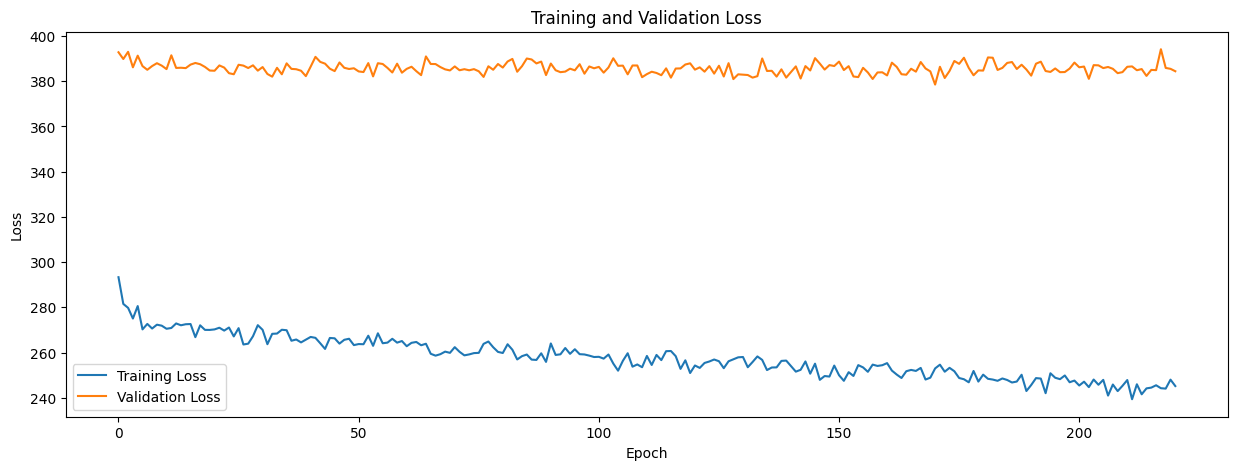

Best Validation Loss: 378.515
Final Training Loss: 245.215
Final Validation Loss: 384.405


In [70]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(valid_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

print(f"Best Validation Loss: {best_valid_loss:.3f}")
print(f"Final Training Loss: {train_losses[-1]:.3f}")
print(f"Final Validation Loss: {valid_losses[-1]:.3f}")


In [71]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model.eval()
all_predictions = []
all_labels = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        all_predictions.extend(outputs.cpu().numpy().flatten())
        all_labels.extend(labels.cpu().numpy().flatten())
predictions = np.array(all_predictions)
labels = np.array(all_labels)
#unweighted metrics
MAE = mean_absolute_error(labels, predictions)
MSE = mean_squared_error(labels, predictions)
RMSE = np.sqrt(MSE)
R2 = r2_score(labels, predictions)
#percentage accuracy
green_zone = np.abs(predictions - labels) <=10
accuracy = (green_zone.sum() / len(predictions)) * 100

print(f"Percentage Accuracy: {accuracy:.2f}%")


print("f. Unweighted Metrics:")
print(f"MAE: {MAE:.3f}")
print(f"MSE: {MSE:.3f}")
print(f"RMSE: {RMSE:.3f}")
print(f"R2: {R2:.3f}")


Percentage Accuracy: 47.25%
f. Unweighted Metrics:
MAE: 14.654
MSE: 383.849
RMSE: 19.592
R2: 0.227


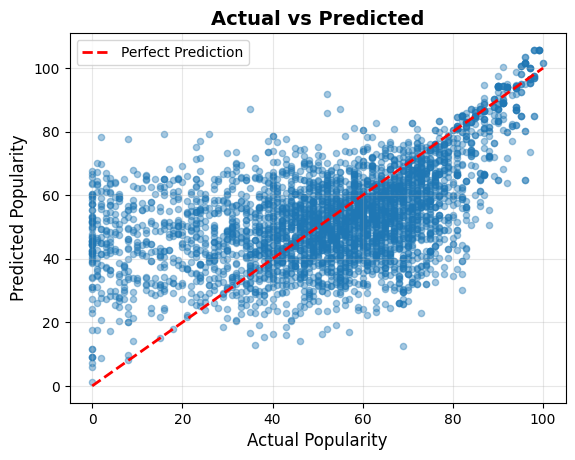

In [72]:
def predictions_1(model, testloader, device):
  model.eval()
  predictions = []
  actuals = []
  with torch.no_grad():
    for inputs, labels in testloader:
      inputs, labels = inputs.to(device), labels.to(device)
      outputs = model(inputs)
      predictions.extend(outputs.cpu().numpy().flatten())
      actuals.extend(labels.cpu().numpy().flatten())
  return np.array(predictions), np.array(actuals)
predictions, actuals = predictions_1(model, test_loader, device)

plt.scatter(actuals, predictions, alpha=0.4, s=20)
plt.plot([0, 100], [0, 100], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Popularity', fontsize=12)
plt.ylabel('Predicted Popularity', fontsize=12)
plt.title('Actual vs Predicted', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

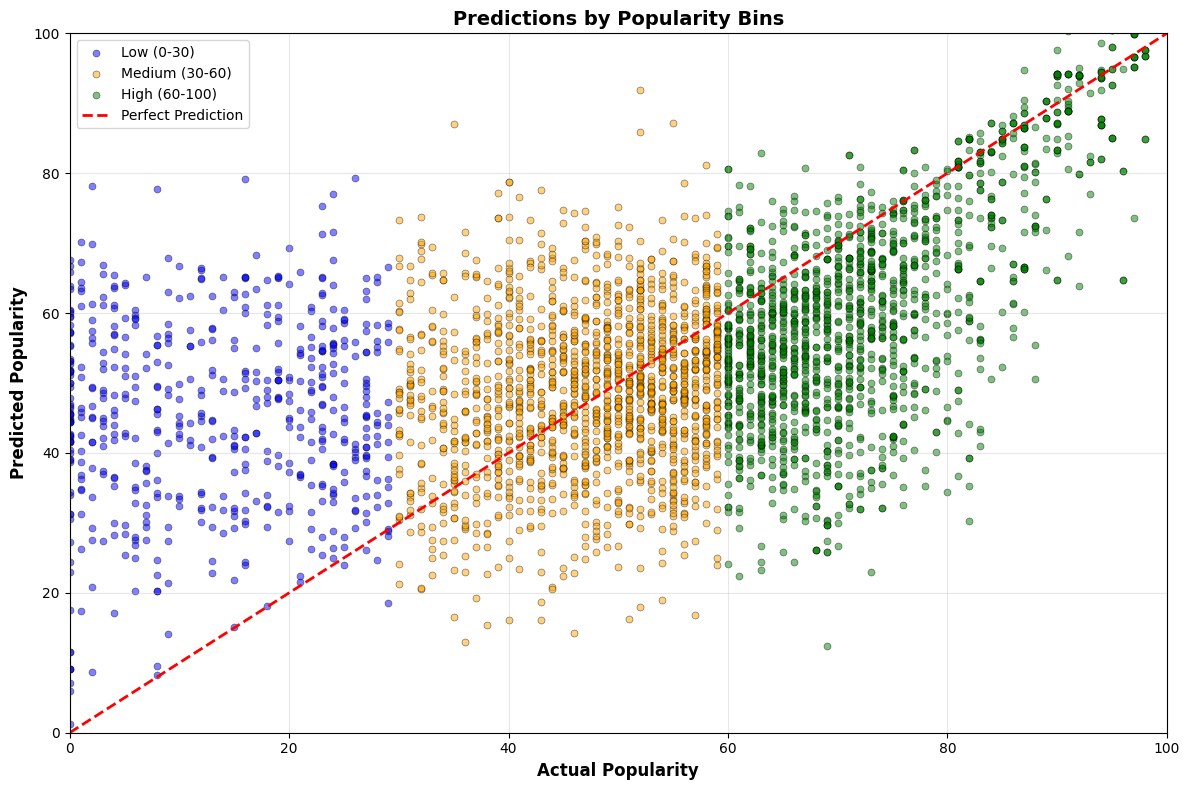

In [73]:
residuals = predictions - actuals
bins = [0, 30, 60, 100]
bin_labels = ['Low (0-30)', 'Medium (30-60)', 'High (60-100)']
bin_colors = ['blue', 'orange', 'green']

fig, ax4 = plt.subplots(figsize=(12, 8))

for i, (low, high) in enumerate(zip(bins[:-1], bins[1:])):
    mask = (actuals >= low) & (actuals < high)
    if mask.sum() > 0:
        plt.scatter(actuals[mask], predictions[mask], alpha=0.5, s=25,
                   color=bin_colors[i], label=bin_labels[i], edgecolors='black', linewidth=0.5)

ax4.plot([0, 100], [0, 100], 'r--', linewidth=2, label='Perfect Prediction')
ax4.set_xlabel('Actual Popularity', fontsize=12, fontweight='bold')
ax4.set_ylabel('Predicted Popularity', fontsize=12, fontweight='bold')
ax4.set_title('Predictions by Popularity Bins', fontsize=14, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0, 100)
ax4.set_ylim(0, 100)

plt.tight_layout()
plt.show()

Save the model

In [74]:
input_size = x_train.shape[1]
output_size = 1
hidden_layers = [128, 64]

checkpointF = {'input_size': input_size, 'output_size': output_size, 'hidden_layers': hidden_layers, 'state_dict': model.state_dict()}
torch.save(checkpointF, 'checkpoint.pth')

In [76]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mean_squared_error(actuals, predictions))
r2 = r2_score(actuals, predictions)
within_10 = (np.abs(residuals) <= 10).sum() / len(residuals) * 100

print("MODEL PERFORMANCE SUMMARY")

print(f"Accuracy (±10 points): {within_10:.2f}%")
print(f"Mean Absolute Error:   {mae:.3f} popularity points")
print(f"Root Mean Squared Error: {rmse:.3f} popularity points")
print(f"R² Score:              {r2:.3f}")


MODEL PERFORMANCE SUMMARY
Accuracy (±10 points): 47.25%
Mean Absolute Error:   14.654 popularity points
Root Mean Squared Error: 19.592 popularity points
R² Score:              0.227


### **Business Impact Analysis:** *Marketing Cost Savings and ROI*

**Advantage Opportunity:** Platforms spend hundreds of millions annually promoting new music releases. Historically, marketing budgets are spread across all releases equally, often leading to wasted spending on songs that won't be popular.

**Solution:** Our song popularity model can be used as a tool to identify high-potential songs before they're released, simply based on musical features. Deployed correctly, streaming platforms could reduce wasted promotional spending on songs unlikely to gain audience engagement.

**Impact:** Shifting marketing expenditure based on popularity prediction could dramatically improve promotional ROI.

In [77]:
import pandas as pd

#Budget assumptions (for large platform)
marketing_budget = 500000000
weekly_releases = 60000
annual_releases = 12000000
current_expenditure_per_song = marketing_budget/annual_releases
current_roi = 1.5 #1.50 for 1 dollar spent (industry average)
current_rev = current_roi * marketing_budget
print(current_expenditure_per_song)
print(current_rev)

#using our model to focus on high-potential songs (70% of budget to high-potential)
high_potential = 0.3
high_potential_budget = 0.7
budget_remains = 0.3

high_potential_count = (annual_releases * high_potential)
remaining_count = annual_releases - high_potential_count

high_potential_buget_allocation = marketing_budget * high_potential_budget
remaining_buget_allocation = marketing_budget * budget_remains

spend_per_high_potential = high_potential_buget_allocation / high_potential_count
spend_per_remaining = remaining_buget_allocation / remaining_count

#ROI Improvement Calculations
#High-potential songs have better conversion rates (roughly 53% better than average)
high_potential_roi = 2.3
remaining_roi = 1.5

revenue_high_potential = high_potential_roi * high_potential_buget_allocation
revenue_remaining = remaining_roi * remaining_buget_allocation
total_new_revenue = revenue_high_potential + revenue_remaining


roi_improvement_pct = (revenue_high_potential - revenue_remaining) / marketing_budget
revenue_improvement = total_new_revenue - current_rev

print(f"\n   Revenue from High-Potential Songs:  ${revenue_high_potential:,.0f}")
print(f"   Revenue from Remaining Songs:       ${revenue_remaining:,.0f}")
print(f"   Total Revenue Generated:            ${total_new_revenue:,.0f}")

print(f"\n   Previous Revenue (No Model):        ${current_rev:,.0f}")
print(f"   Additional Revenue (With Model):    ${revenue_improvement:,.0f}")
print(f"   ROI Improvement:                    {roi_improvement_pct:.1f}%")

print(f"\n  New Marketing ROI:       ${total_new_revenue/marketing_budget:.2f} per $1 spent")

41.666666666666664
750000000.0

   Revenue from High-Potential Songs:  $805,000,000
   Revenue from Remaining Songs:       $225,000,000
   Total Revenue Generated:            $1,030,000,000

   Previous Revenue (No Model):        $750,000,000
   Additional Revenue (With Model):    $280,000,000
   ROI Improvement:                    1.2%

  New Marketing ROI:       $2.06 per $1 spent


**Revenue and ROI Comparison**

/tmp/ipython-input-3670800086.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


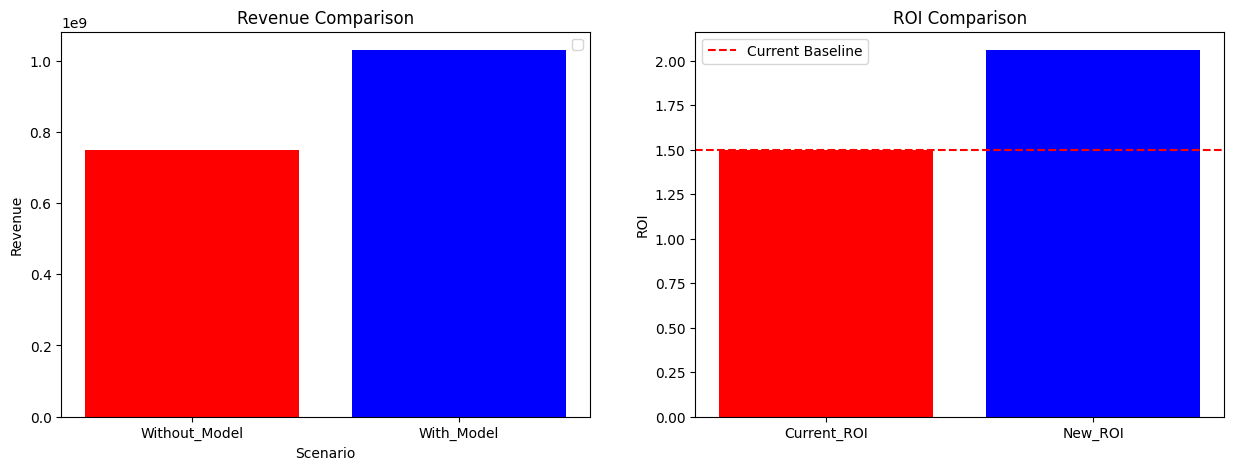

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax1 = axes[0]
scenarios = ["Without_Model", "With_Model"]
revenues = [current_rev, total_new_revenue]
colors = ['red', 'blue']
ax1.bar(scenarios, revenues, color=colors)
ax1.set_xlabel('Scenario')
ax1.set_ylabel('Revenue')
ax1.set_title('Revenue Comparison')
ax1.legend()

ax2 = axes[1]
roi_catagories = ['Current_ROI', 'New_ROI' ]
roi_values = [current_roi, total_new_revenue/marketing_budget]
colors = ['red', 'blue']
ax2.bar(roi_catagories, roi_values, color=colors)
ax2.set_ylabel('ROI')
ax2.set_title('ROI Comparison')
ax2.axhline(y=current_roi, color='red', linestyle='--', label='Current Baseline')
ax2.legend()